In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print(customer_df.shape)
print(customer_df.columns.tolist())

(4312, 7)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']


In [35]:
correlation = customer_df.corr(numeric_only=True)

correlation

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000


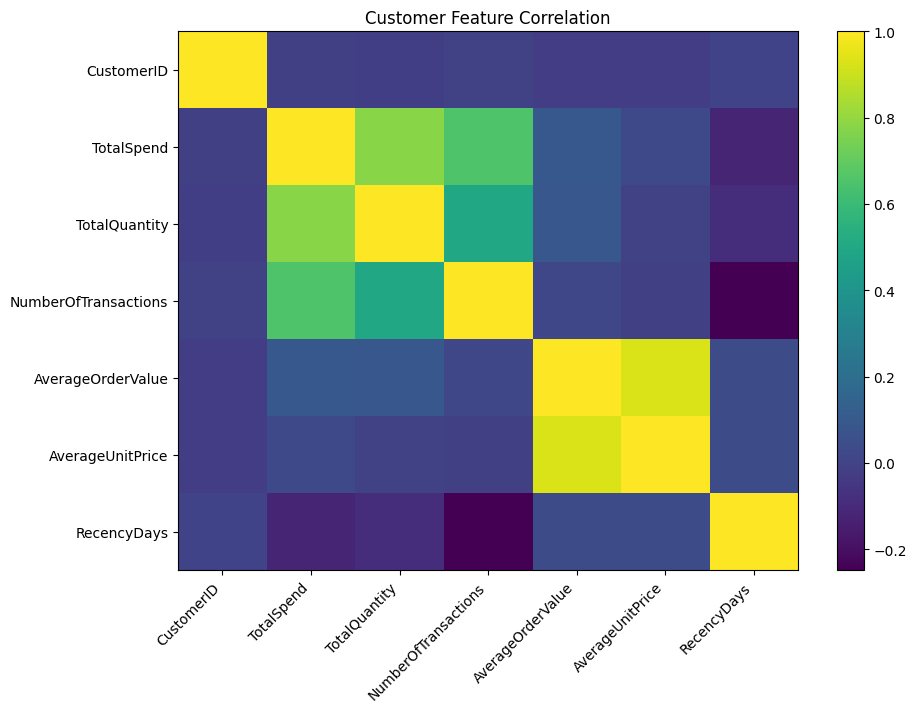

In [67]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Customer Feature Correlation")

plt.show()

In [68]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [69]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

(4312, 7)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
1840,14911,152121.22,69709,205,27.320621,5.668200,1
3996,17850,51208.87,21052,155,20.491745,3.063581,8
251,12748,22457.90,13109,144,8.873133,3.601881,1
2133,15311,55942.74,32784,121,27.449823,2.880849,1
506,13089,57885.45,29125,109,37.539202,2.656530,4
1606,14606,18482.10,9287,102,4.861152,2.852046,2
1269,14156,196549.74,108105,102,74.281837,7.059286,7
939,13694,131443.19,125893,94,137.349206,1.722497,9
3989,17841,29562.02,14332,91,5.979373,3.022502,1
4183,18102,349164.35,124216,89,556.880941,3.491930,1


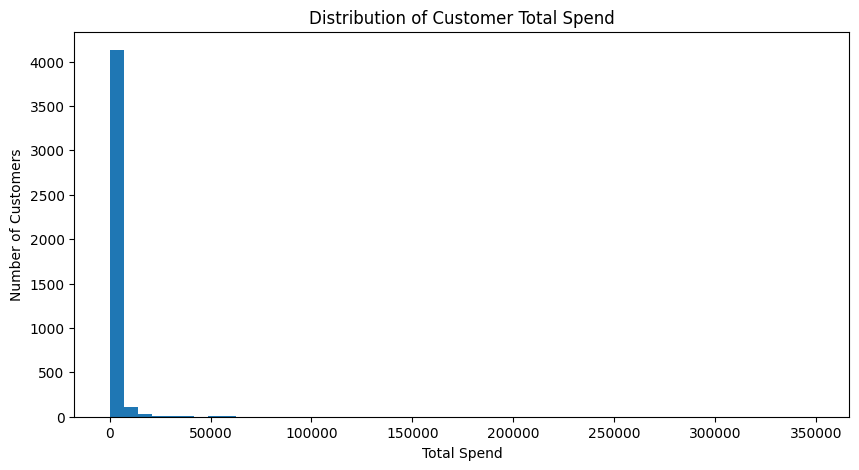

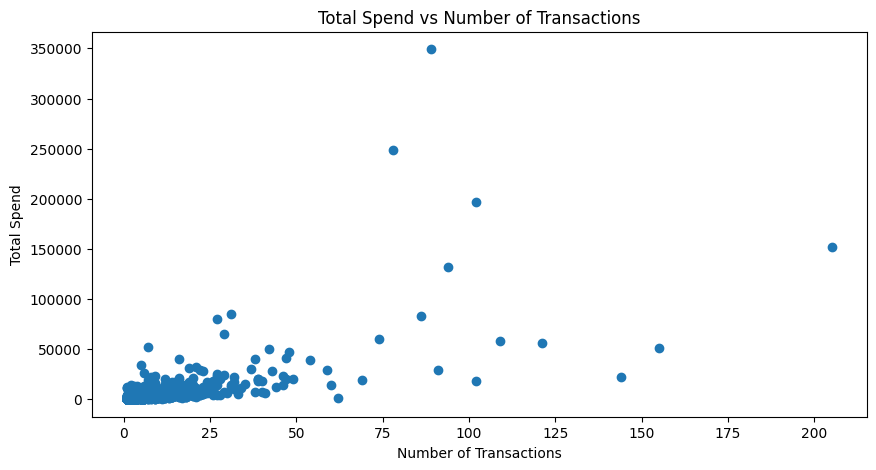

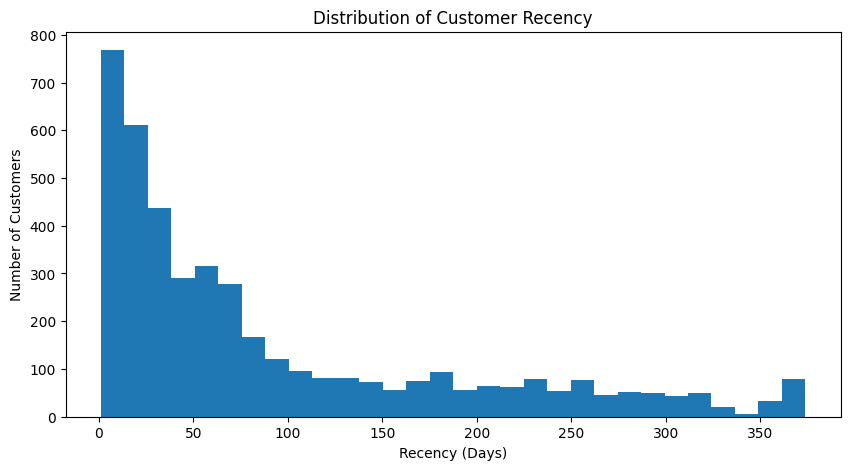

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

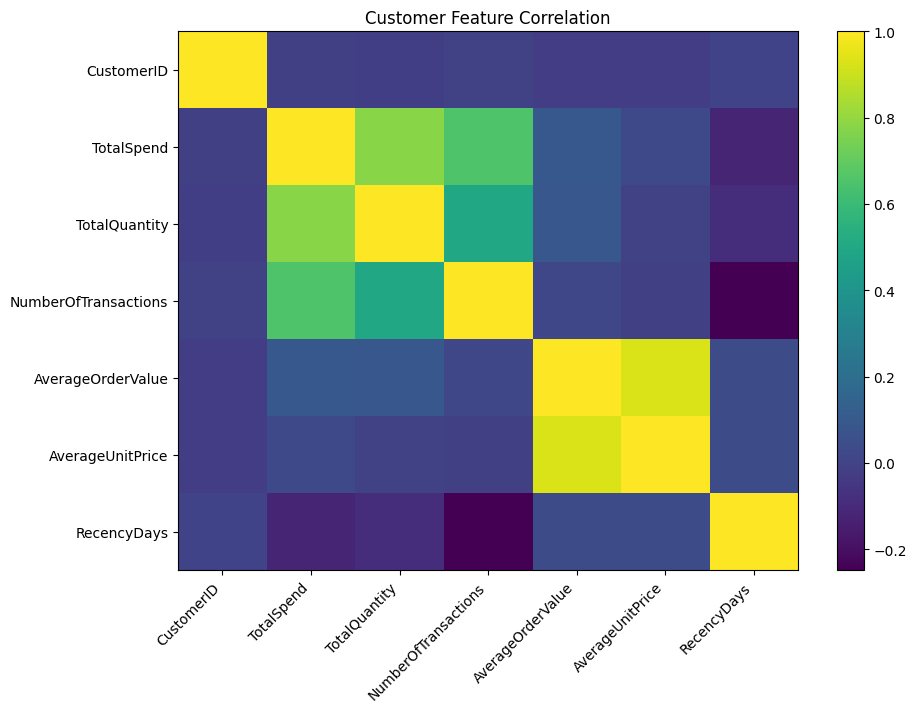

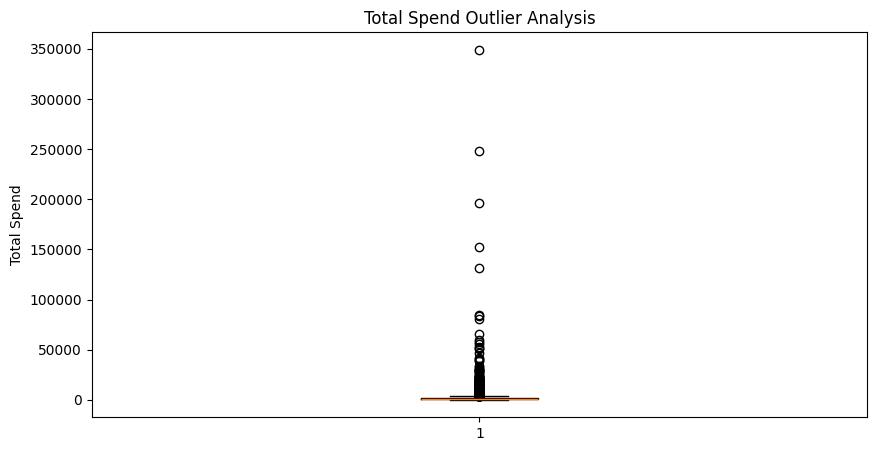

SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64

,count,mean,median,min,max
SpendSegment,,,,,
Low,1438,219.598742,218.405,2.95,399.95
Medium,1437,743.070078,701.620,400.06,1266.77
High,1437,5159.818407,2485.460,1269.05,349164.35


(4312, 8)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']
EDA completed successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print(customer_df.isnull().sum())

display(customer_df.describe())
display(customer_df.head())

top_spenders = customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

display(top_spenders)

top_frequent = customer_df.sort_values(
    "NumberOfTransactions",
    ascending=False
).head(10)

display(top_frequent)

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)
plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(customer_df["RecencyDays"], bins=30)
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")
plt.show()

correlation = customer_df.corr(numeric_only=True)

display(correlation)
display(correlation["TotalSpend"].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
plt.imshow(correlation, aspect="auto")
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.colorbar()
plt.title("Customer Feature Correlation")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(customer_df["TotalSpend"])
plt.ylabel("Total Spend")
plt.title("Total Spend Outlier Analysis")
plt.show()

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
)["TotalSpend"].agg(
    ["count", "mean", "median", "min", "max"]
)

display(segment_analysis)

customer_df.to_csv(
    "../data/processed/customer_features_eda.csv",
    index=False
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print("EDA completed successfully!")

In [2]:
latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (reference_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "RecencyDays"]]

customer_df = customer_df.merge(
    recency,
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,SpendSegment,RecencyDays_y
0,12346,372.86,70,11,11.298788,6.253333,165,Low,165
1,12347,1323.32,828,2,18.638310,2.295070,3,High,3
2,12348,222.16,373,1,11.108000,0.719500,74,Low,74
3,12349,2671.14,993,3,26.187647,8.581765,43,High,43
4,12351,300.93,261,1,14.330000,2.355238,11,Low,11


In [3]:
customer_df.shape

(4312, 9)

In [4]:
customer_df.columns.tolist()

['CustomerID',
 'TotalSpend',
 'TotalQuantity',
 'NumberOfTransactions',
 'AverageOrderValue',
 'AverageUnitPrice',
 'RecencyDays_x',
 'SpendSegment',
 'RecencyDays_y']

In [5]:
customer_df.isnull().sum()

CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays_x           0
SpendSegment            0
RecencyDays_y           0
dtype: int64

In [6]:
customer_df.describe()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,RecencyDays_y
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000,374.000000


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

In [9]:
latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [10]:
customer_df.shape

(4312, 7)

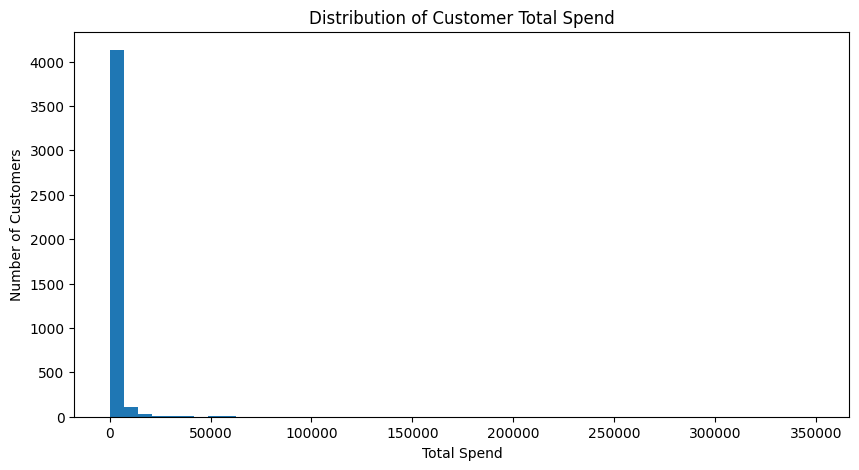

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")
plt.show()

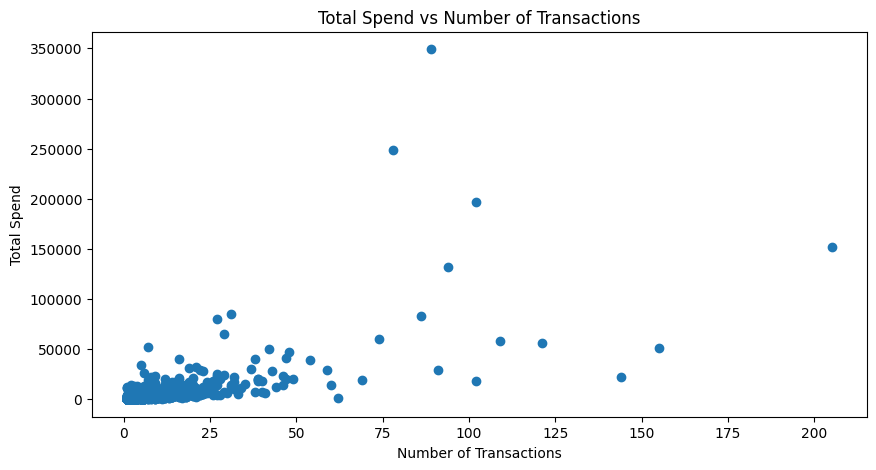

In [12]:
plt.figure(figsize=(10, 5))

plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")

plt.show()

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,RecencyDays_y
0,12346,372.86,70,11,11.298788,6.253333,165,165
1,12347,1323.32,828,2,18.638310,2.295070,3,3
2,12348,222.16,373,1,11.108000,0.719500,74,74
3,12349,2671.14,993,3,26.187647,8.581765,43,43
4,12351,300.93,261,1,14.330000,2.355238,11,11


In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [15]:
df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

print("Rows:", len(df))
print("Columns:", df.shape[1])

Rows: 400916
Columns: 13


In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print("Dataset shape:", customer_df.shape)
print("\nColumns:")
print(customer_df.columns.tolist())

print("\nMissing values:")
print(customer_df.isnull().sum())

print("\nStatistical summary:")
display(customer_df.describe())

customer_df.head()

Dataset shape: (4312, 7)

Columns:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']

Missing values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

Statistical summary:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [18]:
customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7


In [19]:
correlation = customer_df.corr(numeric_only=True)

correlation

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


In [20]:
correlation["TotalSpend"].sort_values(ascending=False)

TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

In [21]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour']


In [22]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    400916 non-null  int64         
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   UnitPrice    400916 non-null  float64       
 6   CustomerID   400916 non-null  int64         
 7   Country      400916 non-null  object        
 8   TotalPrice   400916 non-null  float64       
 9   Year         400916 non-null  int64         
 10  Month        400916 non-null  int64         
 11  Day          400916 non-null  int64         
 12  Hour         400916 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(3)
memory usage: 39.8+ MB


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,400916.000000,400916.000000,400916,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000
mean,514731.380771,13.767418,2010-07-01 05:01:16.167027712,3.305826,15361.544074,21.945330,2009.924493,7.398166,15.365368,12.865191
min,489434.000000,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,7.000000
25%,502752.000000,2.000000,2010-03-26 13:28:00,1.250000,13985.000000,5.000000,2010.000000,4.000000,8.000000,11.000000
50%,515192.000000,5.000000,2010-07-09 10:26:00,1.950000,15311.000000,12.500000,2010.000000,8.000000,15.000000,13.000000
75%,527065.500000,12.000000,2010-10-14 13:58:45,3.750000,16805.000000,19.500000,2010.000000,11.000000,23.000000,14.000000
max,538171.000000,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,2010.000000,12.000000,31.000000,20.000000
std,14090.603233,97.638385,NaN,35.047719,1680.635823,77.758075,0.264208,3.472188,8.735086,2.306906


In [23]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice
0,12346,372.86,70,11,11.298788,6.253333
1,12347,1323.32,828,2,18.638310,2.295070
2,12348,222.16,373,1,11.108000,0.719500
3,12349,2671.14,993,3,26.187647,8.581765
4,12351,300.93,261,1,14.330000,2.355238


In [24]:
print("Original transaction data:", df.shape)
print("Customer-level data:", customer_df.shape)

Original transaction data: (400916, 13)
Customer-level data: (4312, 6)


In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (reference_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "RecencyDays"]]

customer_df = customer_df.merge(recency, on="CustomerID", how="left")

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [26]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [27]:
customer_df.shape

(4312, 7)

In [28]:
customer_df.columns.tolist()

['CustomerID',
 'TotalSpend',
 'TotalQuantity',
 'NumberOfTransactions',
 'AverageOrderValue',
 'AverageUnitPrice',
 'RecencyDays']

In [29]:
customer_df.isnull().sum()

CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

In [30]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice
0,12346,372.86,70,11,11.298788,6.253333
1,12347,1323.32,828,2,18.638310,2.295070
2,12348,222.16,373,1,11.108000,0.719500
3,12349,2671.14,993,3,26.187647,8.581765
4,12351,300.93,261,1,14.330000,2.355238
